In [60]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [84]:
import pandas as pd
import numpy as np
import math, time, random, datetime
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.subplots import make_subplots

In [85]:
db = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
db.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [86]:
db.shape

(1470, 35)

In [87]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

В данных нет пропусков

In [88]:
db.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


В столбце EmployeeCount значение всегда 1. В столбце StandardHours всегда значение 80. Эти столбцы не несут никакой информации.

In [89]:
db_clean = db.copy()
db_clean.drop(['EmployeeCount', 'StandardHours'], axis=1, inplace=True)

In [90]:
db_clean.describe(include=object)

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


Over18 всегда Yes

In [91]:
db_clean.drop(['Over18'], axis=1, inplace=True)
db_clean.duplicated().sum()

np.int64(0)

Дубликатов нет

In [92]:
db_vis = db_clean.copy()

education_map = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}
db_vis['Education'] = db_vis['Education'].map(education_map)

satisfaction_map = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}
db_vis['EnvironmentSatisfaction'] = db_vis['EnvironmentSatisfaction'].map(satisfaction_map)

db_vis['JobInvolvement'] = db_vis['JobInvolvement'].map(satisfaction_map)

db_vis['JobSatisfaction'] = db_vis['JobSatisfaction'].map(satisfaction_map)

db_vis['RelationshipSatisfaction'] = db_vis['RelationshipSatisfaction'].map(satisfaction_map)

performance_rating_map = {
    1: 'Low',
    2: 'Good',
    3: 'Excellent',
    4: 'Outstanding'
}
db_vis['PerformanceRating'] = db_vis['PerformanceRating'].map(performance_rating_map)

worklife_map = {
    1: 'Bad',
    2: 'Good',
    3: 'Better',
    4: 'Best'
}
db_vis['WorkLifeBalance'] = db_vis['WorkLifeBalance'].map(worklife_map)

In [93]:
db_vis.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,1,Medium,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,2,High,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,4,Very High,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,5,Very High,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,7,Low,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [94]:
db_vis.describe(include='object')

,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobRole,JobSatisfaction,MaritalStatus,OverTime,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,5,6,4,2,4,9,4,3,2,2,4,4
top,No,Travel_Rarely,Research & Development,Bachelor,Life Sciences,High,Male,High,Sales Executive,Very High,Married,No,Excellent,High,Better
freq,1233,1043,961,572,606,453,882,868,326,459,673,1054,1244,459,893


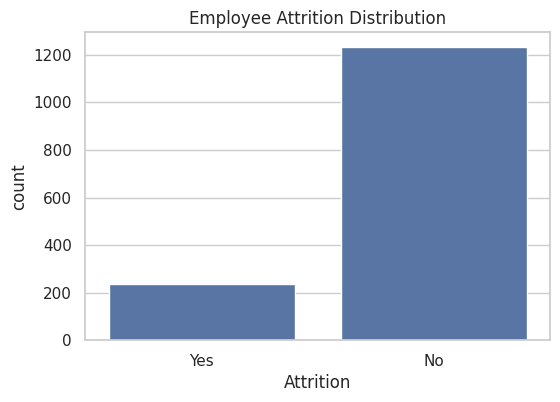

In [95]:
plt.figure(figsize=(6,4))
sns.countplot(data=db_vis, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.show()

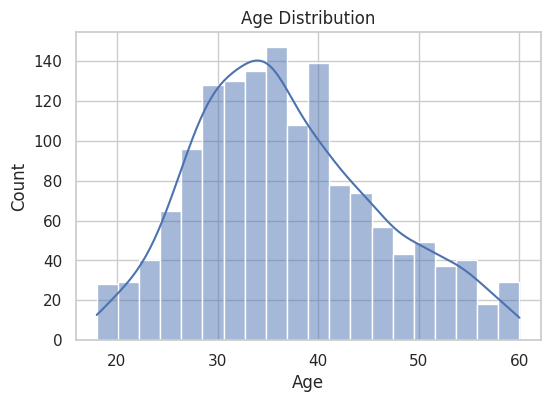

In [96]:
plt.figure(figsize=(6,4))
sns.histplot(db_vis["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

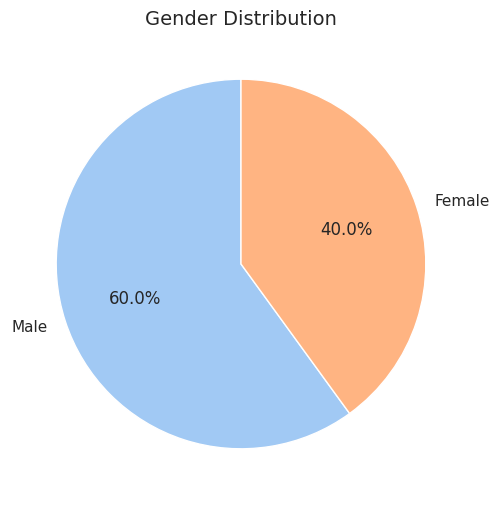

In [97]:
colors = sns.color_palette("pastel")

plt.figure(figsize=(6,6))
plt.pie(
    db_clean["Gender"].value_counts(),
    labels=db_clean["Gender"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Gender Distribution", fontsize=14)
plt.show()

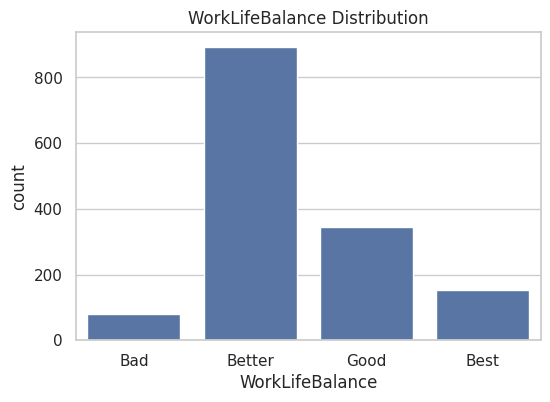

In [98]:
plt.figure(figsize=(6,4))
sns.countplot(data=db_vis, x="WorkLifeBalance")
plt.title("WorkLifeBalance Distribution")
plt.show()

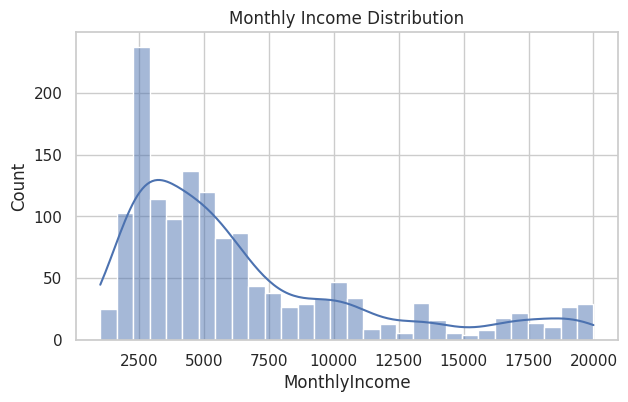

In [99]:
plt.figure(figsize=(7,4))
sns.histplot(db_vis["MonthlyIncome"], kde=True, bins=30)
plt.title("Monthly Income Distribution")
plt.show()

In [100]:
attrition = db_clean[db_clean['Attrition']=='Yes']
no_attrition = db_clean[db_clean['Attrition']=='No']

In [101]:
def numerical_column_viz(col_name):
    f, ax = plt.subplots(1, 2, figsize=(16, 5))

    sns.kdeplot(attrition[col_name], fill=True, label='Left', color='salmon', ax=ax[0])
    sns.kdeplot(no_attrition[col_name], fill=True, label='Stayed', color='green', ax=ax[0])
    ax[0].set_title(f'Distribution of {col_name}')

    sns.boxplot(x='Attrition', y=col_name, data=db_vis, ax=ax[1])

    plt.show()

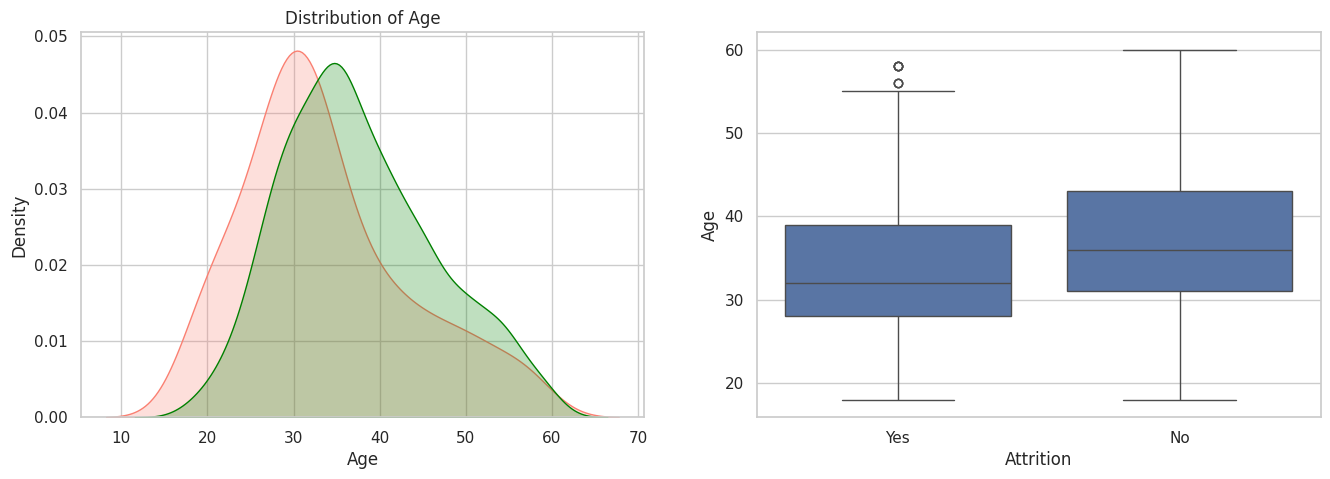

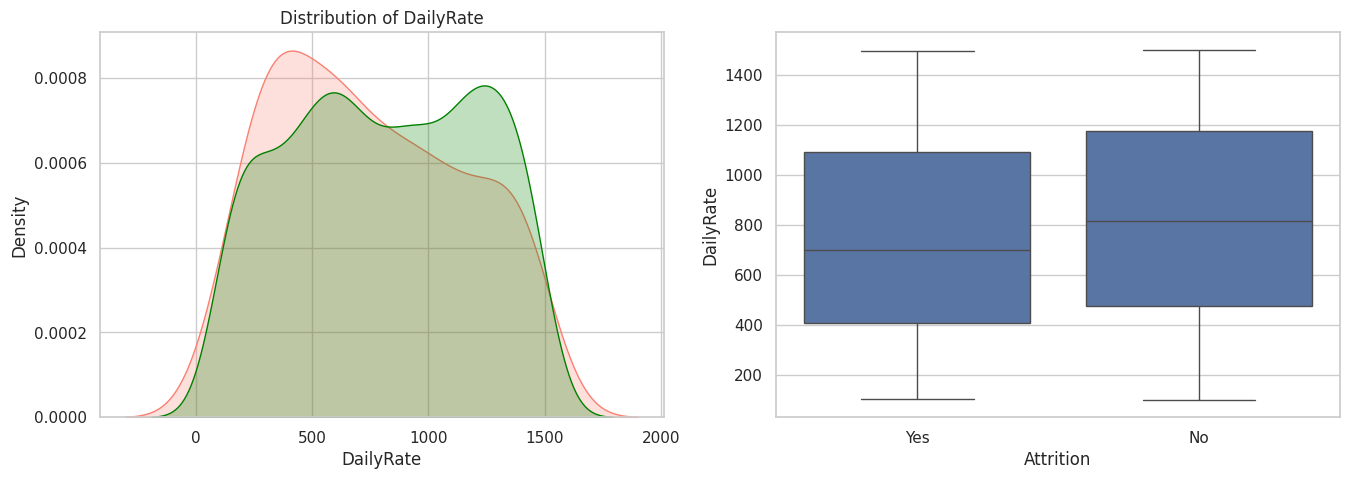

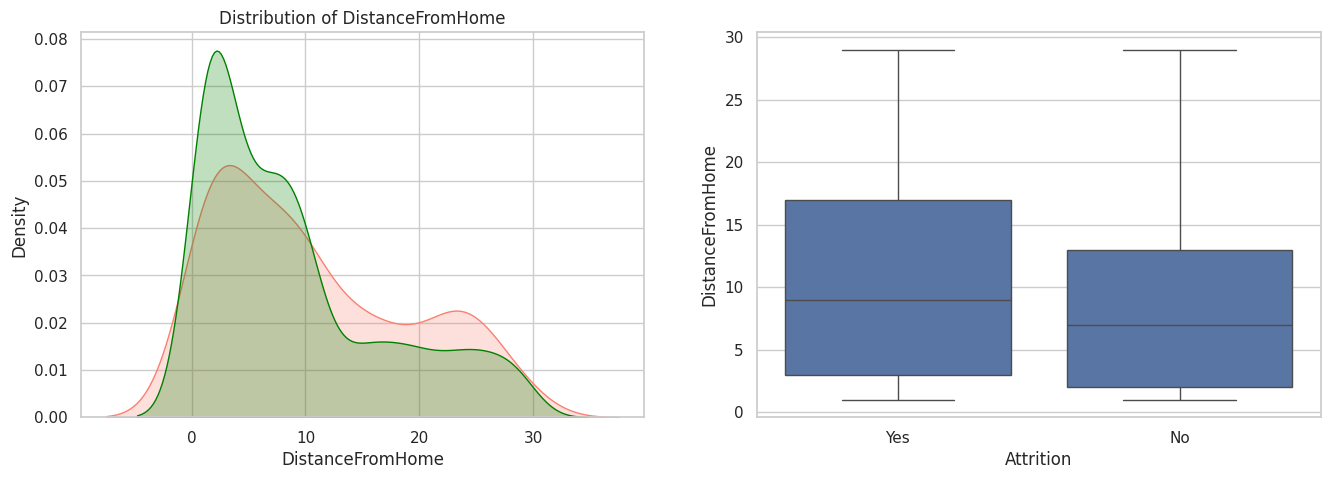

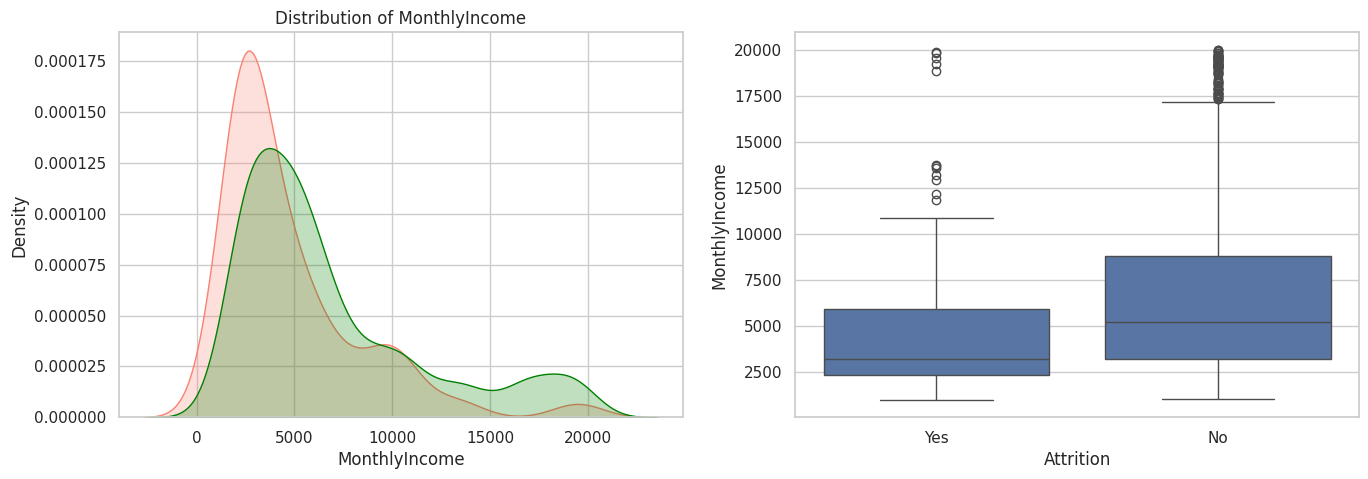

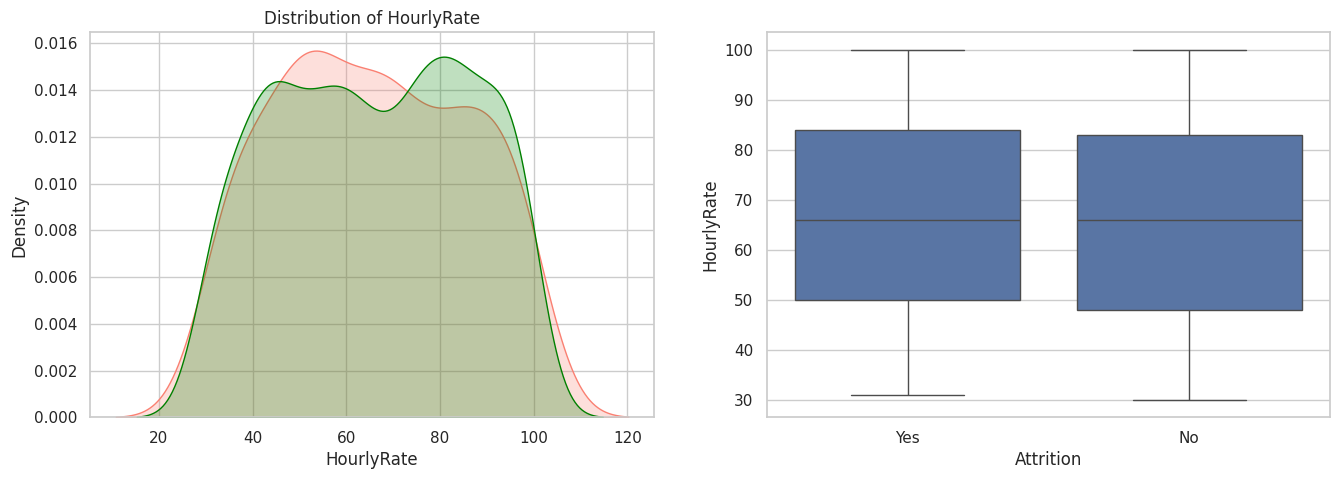

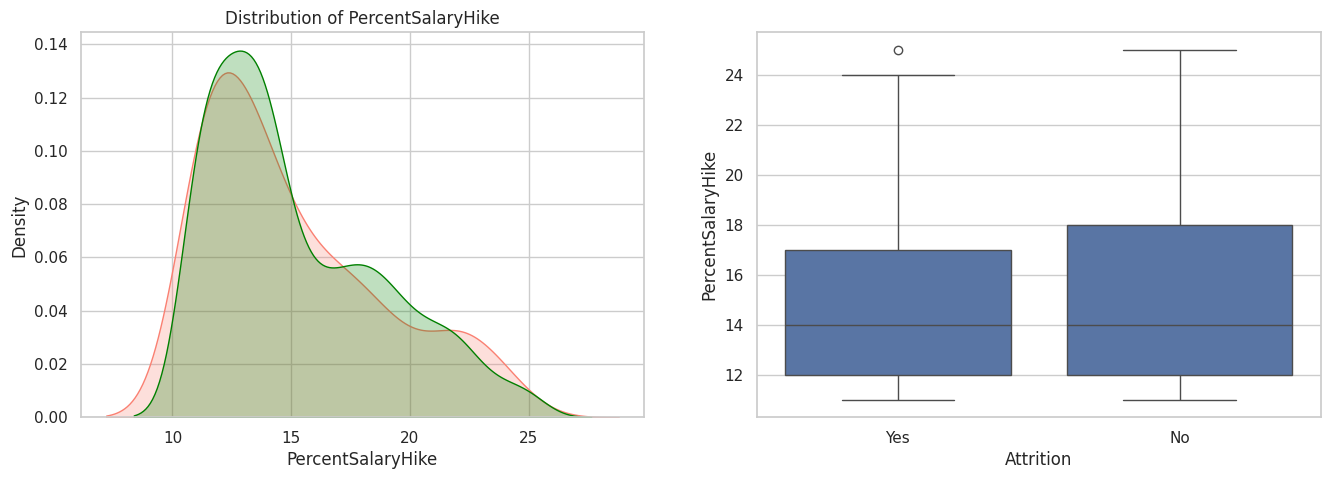

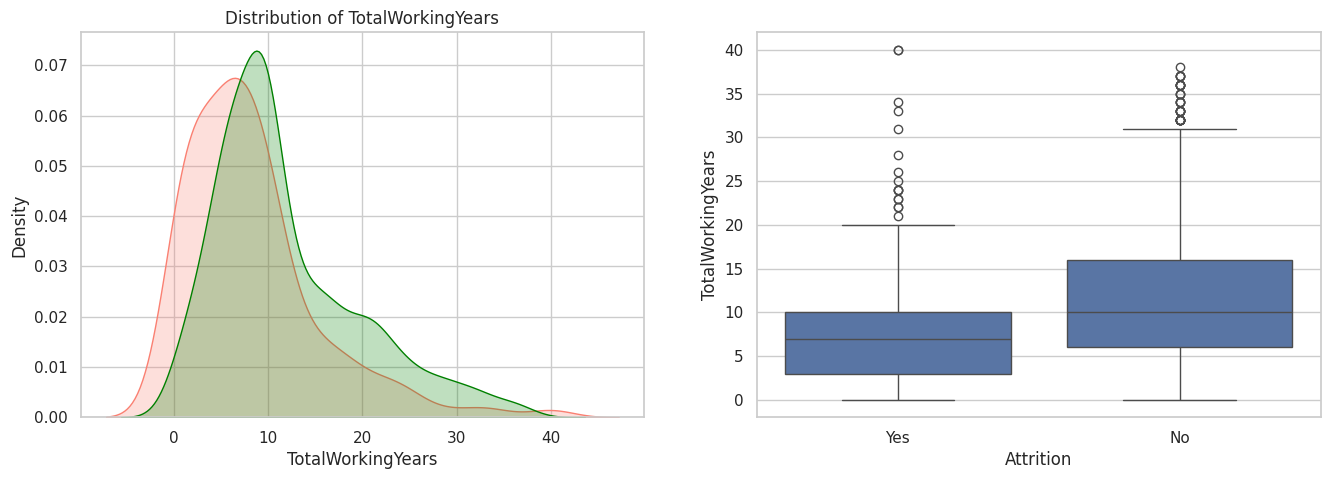

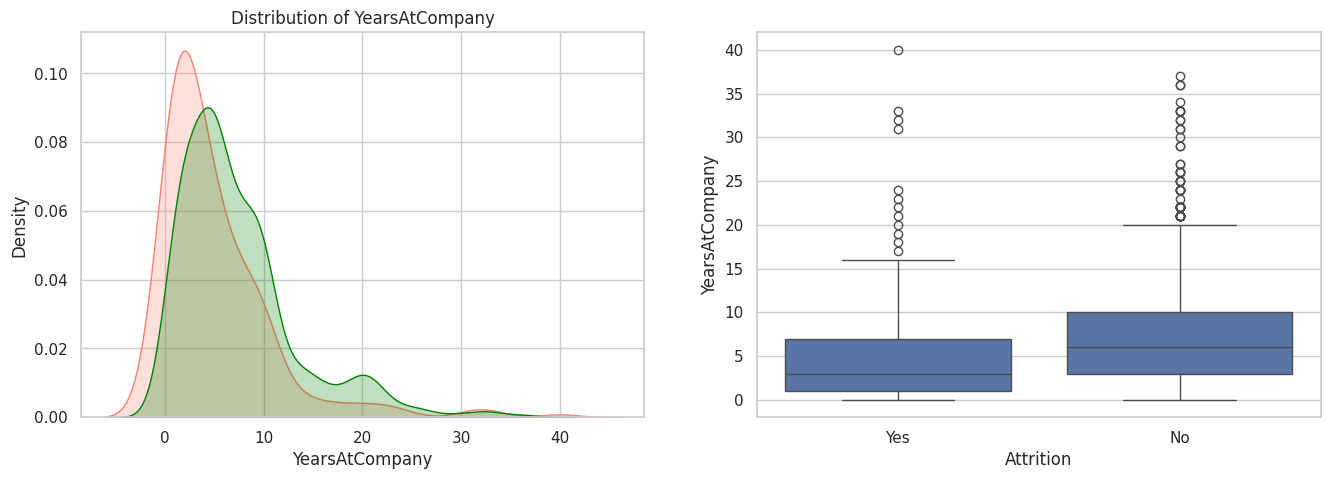

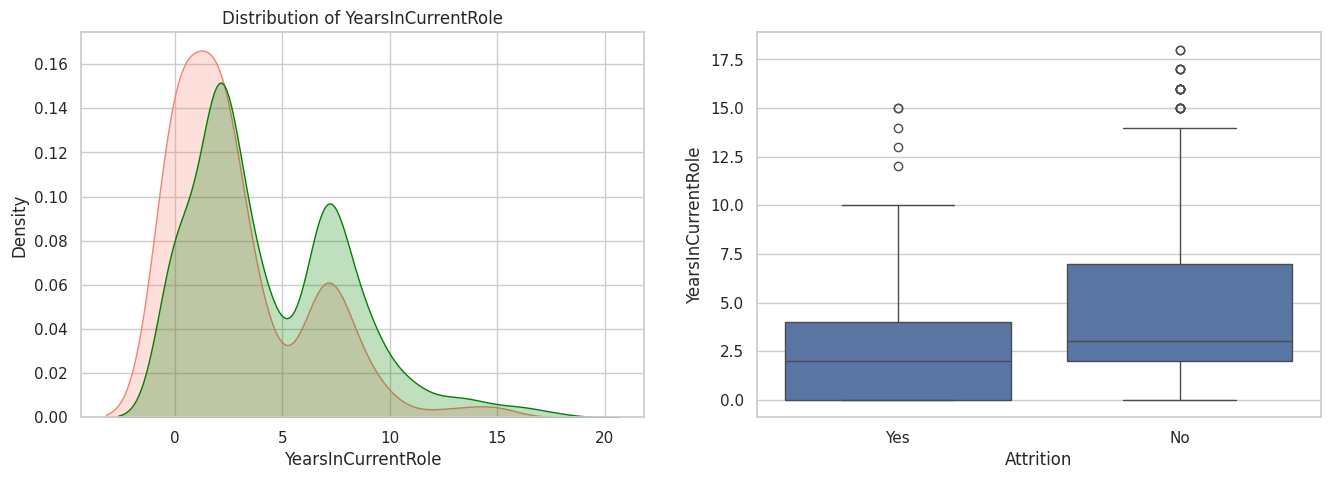

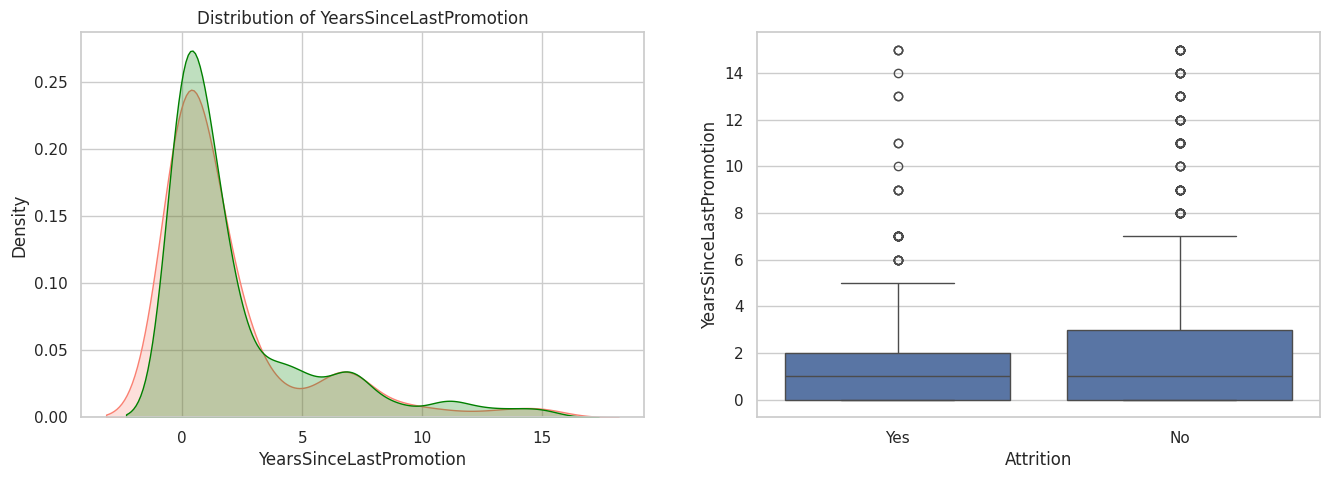

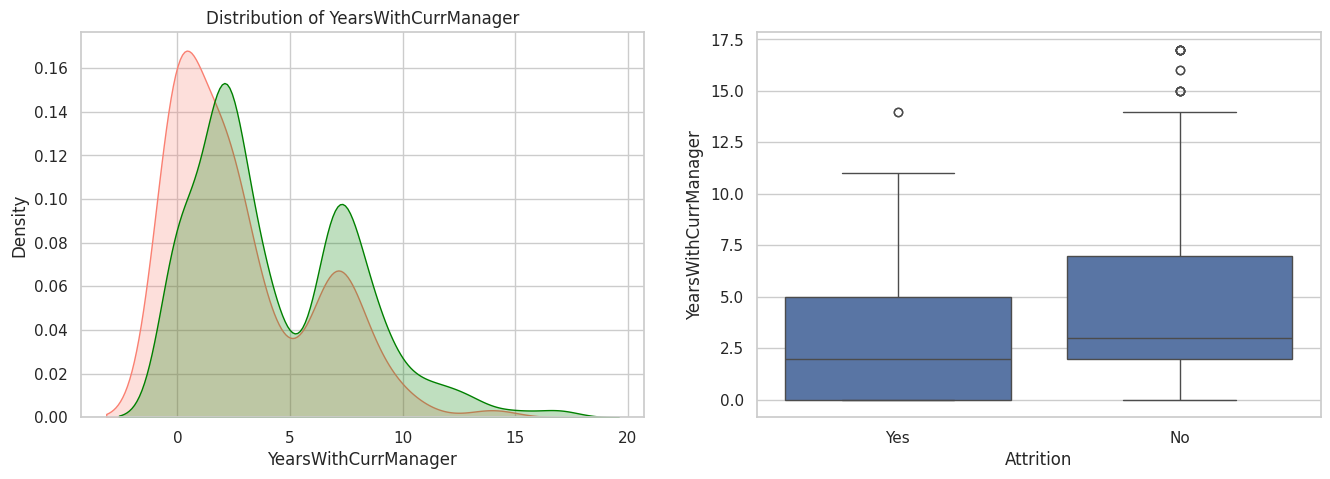

In [102]:
numerical_columns = [
    "Age","DailyRate","DistanceFromHome","MonthlyIncome","HourlyRate",
    "PercentSalaryHike","TotalWorkingYears","YearsAtCompany",
    "YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager"
]

for col in numerical_columns:
    numerical_column_viz(col)

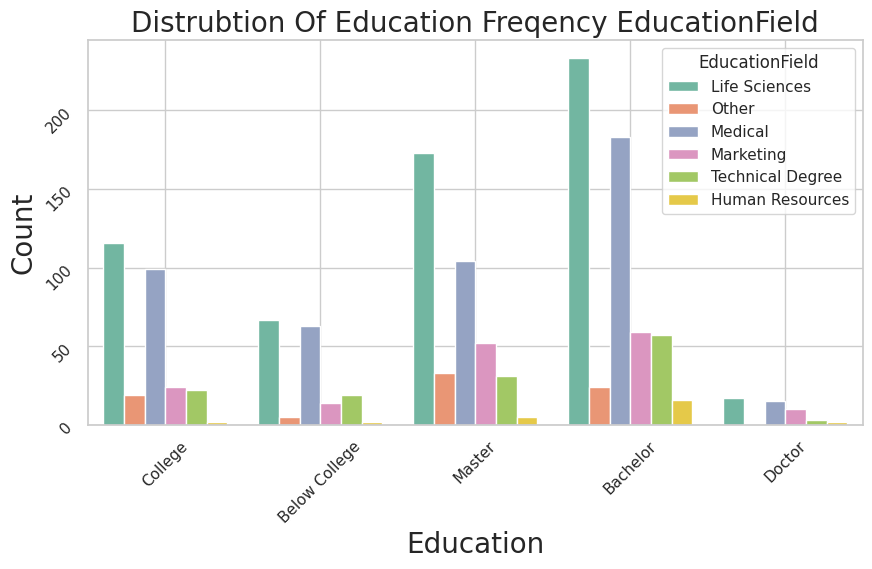

In [103]:
plt.figure(figsize=(10,5))

sns.countplot(x='Education',hue='EducationField',data=db_vis,palette='Set2')
plt.grid(True)
plt.title('Distrubtion Of Education Freqency EducationField',fontsize=20)
plt.xlabel('Education',fontsize=20)
plt.ylabel('Count',fontsize=20)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

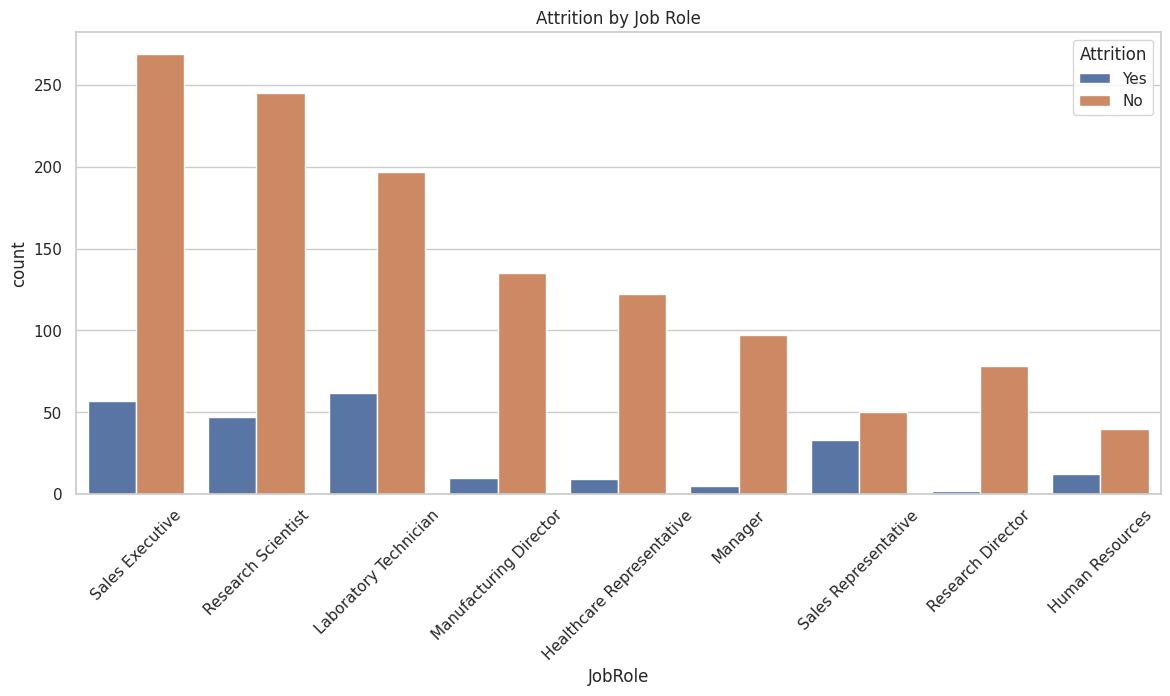

In [104]:
plt.figure(figsize=(14,6))
sns.countplot(data=db_vis, x="JobRole", hue="Attrition")
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

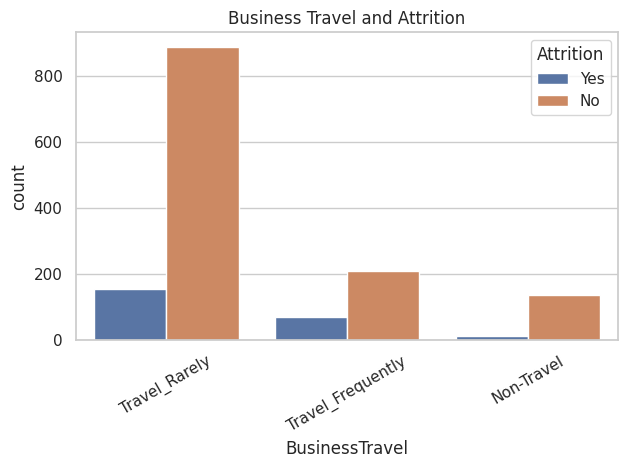

In [105]:
plt.figure(figsize=(7,4))
sns.countplot(data=db_clean, x="BusinessTravel", hue="Attrition")
plt.title("Business Travel and Attrition")
plt.xticks(rotation=30)
plt.show()

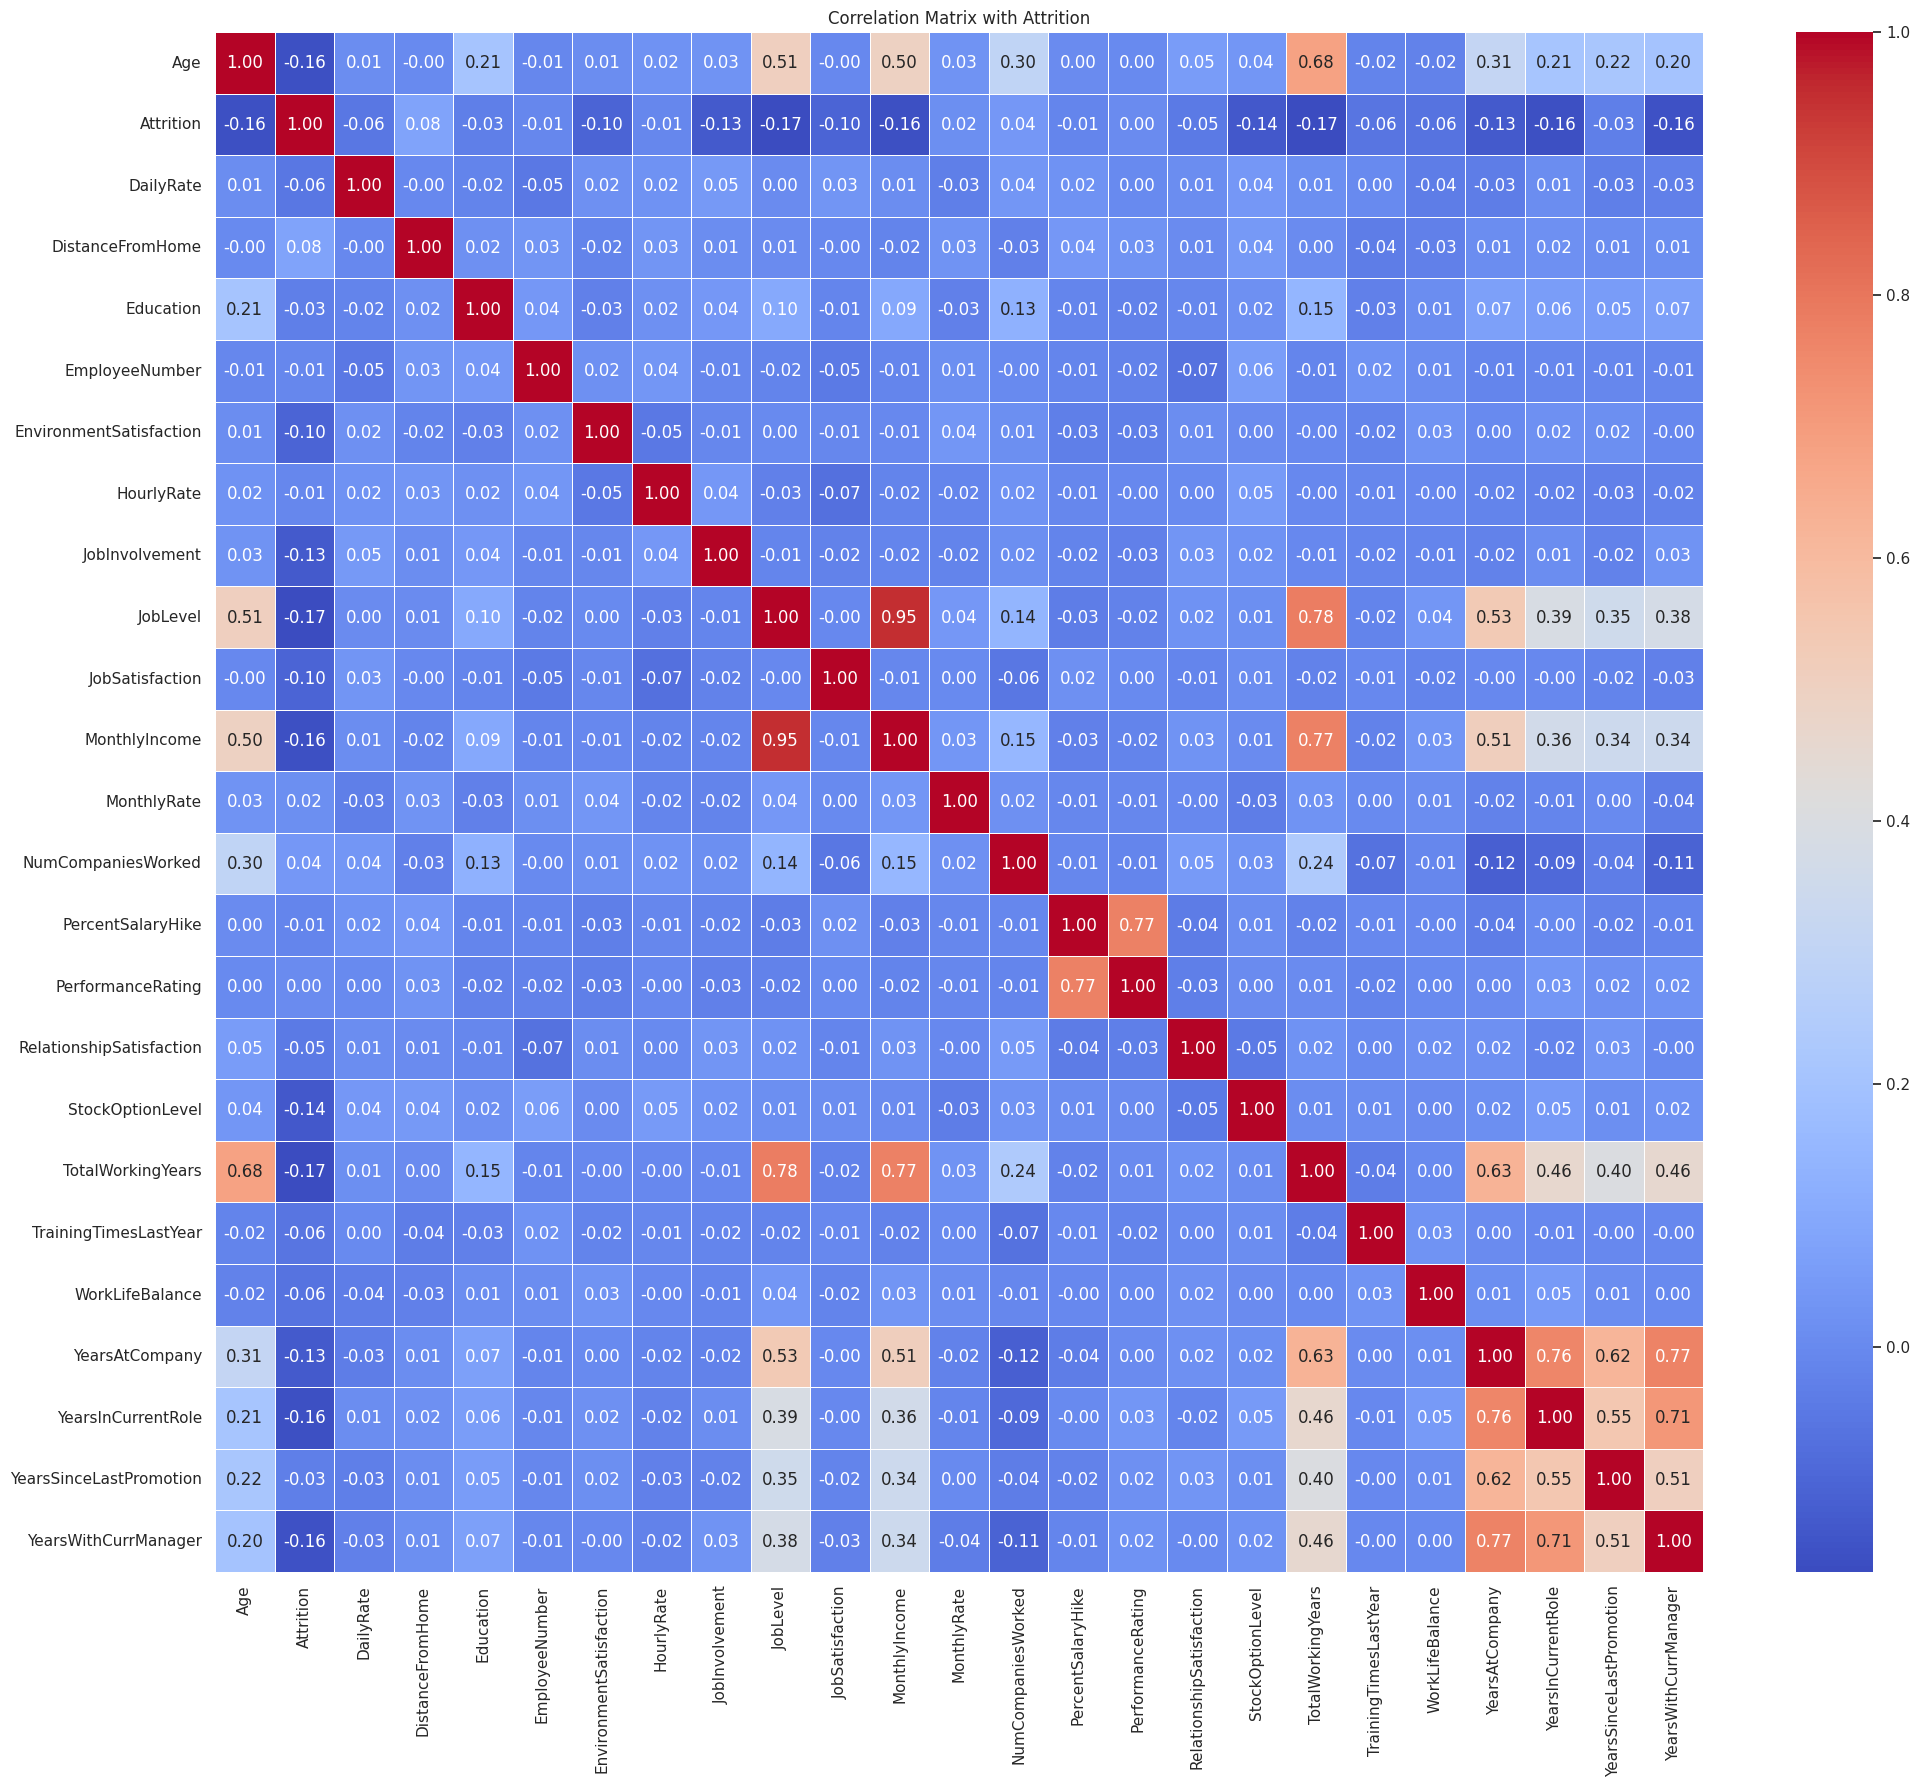

In [106]:
db_corr = db_clean.copy()

db_corr['Attrition'] = db_corr['Attrition'].map({"Yes":1,"No":0})
numeric_cols = db_corr.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(24,20))
sns.heatmap(db_corr[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix with Attrition")
plt.show()

MonthlyIncome и JobLevel имеют большую корреляцию. Это может создать проблему мультиколлинеарности.